In [1]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting

# Machine Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Evaluation Metrics
from cuml.metrics import regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Print library versions
print(f"cuDF Version: {cudf.__version__}")
print(f"CuPy Version: {cp.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# GPU Check
from numba import cuda

if cuda.is_available():
    print("\nGPU Detected:")
    device = cuda.get_current_device()
    print(f"Device Name: {device.name}") 
else:
    print("Warning: No GPU detected - Falling back to CPU mode")

2025-07-21 02:22:41.810494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 02:22:42.042920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-21 02:22:42.106002: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-21 02:22:42.115685: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-21 02:22:42.228792: I tensorflow/core/platform/cpu_feature_guar

cuDF Version: 24.10.01
CuPy Version: 13.3.0
TensorFlow Version: 2.17.0

GPU Detected:
Device Name: b'NVIDIA GeForce RTX 4050 Laptop GPU'


In [2]:
def load_datasets():
    """
    Memuat dataset Harga.csv dan Triwulan.csv dengan cudf.
    Mengembalikan tuple (harga_df, triwulan_df).
    """
    try:
        # Load Harga.csv (data harian)
        harga_df = cudf.read_csv('/home/rna_13/ModelPredict/harga.csv', parse_dates=['Tanggal'], skipinitialspace=True)
        
        # Load Triwulan.csv (data produksi)
        triwulan_df = cudf.read_csv('/home/rna_13/ModelPredict/produksi.csv', skipinitialspace=True)
        
        # Validasi keberadaan kolom penting
        required_harga_cols = {'Komoditi', 'Tanggal', ' Harga Petani ', ' Harga Pengecer '}
        required_triwulan_cols = {'Komoditi', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas', 'Produksi'}
        
        assert required_harga_cols.issubset(harga_df.columns), "Kolom tidak valid di Harga.csv"
        assert required_triwulan_cols.issubset(triwulan_df.columns), "Kolom tidak valid di Triwulan.csv"
        
        print("✔ Dataset berhasil dimuat")
        print(f"- Harga.csv: {len(harga_df)} baris")
        print(f"- Triwulan.csv: {len(triwulan_df)} baris")
        
        return harga_df, triwulan_df
    
    except FileNotFoundError as e:
        print(f"❌ File tidak ditemukan: {e}")
        return None, None
    except Exception as e:
        print(f"❌ Error saat memuat dataset: {e}")
        return None, None

# Contoh penggunaan
harga_df, triwulan_df = load_datasets()

if harga_df is not None:
    print("\n5 baris pertama harga.csv:")
    print(harga_df.head())

if triwulan_df is not None:
    print("\n5 baris pertama Produksi.csv:")
    print(triwulan_df.head())

✔ Dataset berhasil dimuat
- Harga.csv: 4382 baris
- Triwulan.csv: 30 baris

5 baris pertama harga.csv:
              Komoditi    Tanggal   Harga Petani    Harga Pengecer 
0  Jagung Pipil Kering 2022-01-03            4800              5000
1  Jagung Pipil Kering 2022-01-04            4800              5000
2  Jagung Pipil Kering 2022-01-05            4800              5000
3  Jagung Pipil Kering 2022-01-06            4800              5000
4  Jagung Pipil Kering 2022-01-07            4800              5000

5 baris pertama Produksi.csv:
     Komoditi  tahun  triwulan  Luas Panen  Produktivitas   Produksi
0  Padi sawah   2022         1  35685.6200      56.593625  201957.86
1  Padi sawah   2022         2  12599.0000      54.279752   68387.06
2  Padi sawah   2022         3   6888.7897      55.240632   38054.11
3  Padi sawah   2023         1  26790.3606      55.977470  149965.66
4  Padi sawah   2023         2  21687.8044      58.797478  127518.82


In [3]:
harga_df = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

In [4]:
harga_df['Komoditi'].unique()

0    Jagung Pipil Kering
1           Beras Medium
2          Beras Premium
3           Kacang Hijau
Name: Komoditi, dtype: object

In [5]:
df_harga = harga_df[harga_df['Komoditi'] == 'Jagung Pipil Kering']

In [6]:
df_harga['Tipe'] = 'Undefined'

In [7]:
df_harga['Periode'] = '0'

In [8]:
df_harga=df_harga.sort_values(by='Tanggal')
df_harga=df_harga.reset_index()
df_harga=df_harga.drop(columns=['index'])


In [9]:
df_harga

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Jagung Pipil Kering,2022-01-03,4800,5000,Undefined,0
1,Jagung Pipil Kering,2022-01-04,4800,5000,Undefined,0
2,Jagung Pipil Kering,2022-01-05,4800,5000,Undefined,0
3,Jagung Pipil Kering,2022-01-06,4800,5000,Undefined,0
4,Jagung Pipil Kering,2022-01-07,4800,5000,Undefined,0
...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Undefined,0
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Undefined,0
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Undefined,0
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Undefined,0


In [10]:
q1_2022_start = pd.to_datetime('2022-01-01')
q1_2022_end = pd.to_datetime('2022-04-30')

q2_2022_start = pd.to_datetime('2022-05-01')
q2_2022_end = pd.to_datetime('2022-08-31')

q3_2022_start = pd.to_datetime('2022-09-01')
q3_2022_end = pd.to_datetime('2022-12-31')

q1_2023_start = pd.to_datetime('2023-01-01')
q1_2023_end = pd.to_datetime('2023-04-30')

q2_2023_start = pd.to_datetime('2023-05-01')
q2_2023_end = pd.to_datetime('2023-08-31')

q3_2023_start = pd.to_datetime('2023-09-01')
q3_2023_end = pd.to_datetime('2023-12-31')

q1_2024_start = pd.to_datetime('2024-01-01')
q1_2024_end = pd.to_datetime('2024-04-30')

q2_2024_start = pd.to_datetime('2024-05-01')
q2_2024_end = pd.to_datetime('2024-08-31')

q3_2024_start = pd.to_datetime('2024-09-01')
q3_2024_end = pd.to_datetime('2024-12-31')

In [11]:
df_harga.loc[(df_harga['Tanggal'] >= q1_2022_start) & (df_harga['Tanggal'] <= q1_2022_end), 'Periode'] = 'Q1-2022'
df_harga.loc[(df_harga['Tanggal'] >= q2_2022_start) & (df_harga['Tanggal'] <= q2_2022_end), 'Periode'] = 'Q2-2022'
df_harga.loc[(df_harga['Tanggal'] >= q3_2022_start) & (df_harga['Tanggal'] <= q3_2022_end), 'Periode'] = 'Q3-2022'
df_harga.loc[(df_harga['Tanggal'] >= q1_2023_start) & (df_harga['Tanggal'] <= q1_2023_end), 'Periode'] = 'Q1-2023'
df_harga.loc[(df_harga['Tanggal'] >= q2_2023_start) & (df_harga['Tanggal'] <= q2_2023_end), 'Periode'] = 'Q2-2023'
df_harga.loc[(df_harga['Tanggal'] >= q3_2023_start) & (df_harga['Tanggal'] <= q3_2023_end), 'Periode'] = 'Q3-2023'
df_harga.loc[(df_harga['Tanggal'] >= q1_2024_start) & (df_harga['Tanggal'] <= q1_2024_end), 'Periode'] = 'Q1-2024'
df_harga.loc[(df_harga['Tanggal'] >= q2_2024_start) & (df_harga['Tanggal'] <= q2_2024_end), 'Periode'] = 'Q2-2024'
df_harga.loc[(df_harga['Tanggal'] >= q3_2024_start) & (df_harga['Tanggal'] <= q3_2024_end), 'Periode'] = 'Q3-2024'

In [12]:
triwulan_df['Tipe'] = 'Undefined'

In [13]:
triwulan_df.loc[(triwulan_df['Komoditi'] == 'Padi sawah'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi gogo'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi total'), 'Tipe'] = 'Padi'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'jagung'), 'Tipe'] = 'Jagung'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'kacang hijau'), 'Tipe'] = 'Kacang Hijau'

In [14]:
df_harga.loc[(df_harga['Komoditi'] == 'Jagung Pipil Kering'), 'Tipe'] = 'Jagung'

In [15]:
df_harga

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Jagung Pipil Kering,2022-01-03,4800,5000,Jagung,Q1-2022
1,Jagung Pipil Kering,2022-01-04,4800,5000,Jagung,Q1-2022
2,Jagung Pipil Kering,2022-01-05,4800,5000,Jagung,Q1-2022
3,Jagung Pipil Kering,2022-01-06,4800,5000,Jagung,Q1-2022
4,Jagung Pipil Kering,2022-01-07,4800,5000,Jagung,Q1-2022
...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Jagung,Q3-2024
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Jagung,Q3-2024
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Jagung,Q3-2024
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Jagung,Q3-2024


In [16]:
triwulan_df['Periode'] = "Q" + triwulan_df['triwulan'].astype(str) + "-" + triwulan_df['tahun'].astype(str)

In [17]:
df_merged = cudf.merge(
    df_harga,
    triwulan_df,
    left_on=['Periode', 'Tipe'], # Kolom dari df_penjualan
    right_on=['Periode', 'Tipe'],       # Kolom dari df_kehadiran
    how='left'                               # Pilih jenis join sesuai kebutuhanmu
)

In [18]:
df_merged=df_merged.sort_values(by='Tanggal')
df_merged=df_merged.reset_index()
df_merged=df_merged.drop(columns=['index', 'triwulan'])
df_merged

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,Komoditi_y,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2022-01-03,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
1,Jagung Pipil Kering,2022-01-04,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
2,Jagung Pipil Kering,2022-01-05,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
3,Jagung Pipil Kering,2022-01-06,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
4,Jagung Pipil Kering,2022-01-07,4800,5000,Jagung,Q1-2022,jagung,2022,70654.48313,73.8989014,522128.8683
...,...,...,...,...,...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900,4000,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1090,Jagung Pipil Kering,2024-12-28,3900,4000,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1091,Jagung Pipil Kering,2024-12-29,3900,4000,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1092,Jagung Pipil Kering,2024-12-30,<NA>,<NA>,Jagung,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>


In [19]:
df_merged=df_merged.drop(columns=['Komoditi_y'])
df_merged = df_merged.rename(columns={'Komoditi_x' : 'Komoditi'})

In [20]:
df_merged=df_merged.to_pandas()

In [21]:
df_merged

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2022-01-03,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
1,Jagung Pipil Kering,2022-01-04,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
2,Jagung Pipil Kering,2022-01-05,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
3,Jagung Pipil Kering,2022-01-06,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
4,Jagung Pipil Kering,2022-01-07,4800.0,5000.0,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.8683
...,...,...,...,...,...,...,...,...,...,...
1089,Jagung Pipil Kering,2024-12-27,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
1090,Jagung Pipil Kering,2024-12-28,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
1091,Jagung Pipil Kering,2024-12-29,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
1092,Jagung Pipil Kering,2024-12-30,NaN,NaN,Jagung,Q3-2024,NaN,NaN,NaN,NaN


In [22]:
df_train=df_merged[(df_merged['Tanggal'] >= '2022-01-01') & (df_merged['Tanggal'] <= '2023-12-31')].copy()

In [23]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import pandas as pd

def stl_imputation(series, period=30):
    """
    Mengisi missing value (NaN) dalam deret waktu menggunakan dekomposisi STL.
    
    Argumen:
    series (pd.Series): Deret waktu dengan kemungkinan missing value (NaN).
    period (int): Periode musiman deret waktu (misal 30 untuk data harian bulanan).

    Mengembalikan:
    pd.Series: Deret waktu dengan missing value yang sudah diisi.
    """
    
    # Pastikan series adalah Pandas Series dan indeksnya berupa datetime
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    
    # Buat salinan seri untuk bekerja, agar tidak mengubah seri asli
    imputed_series = series.copy()
    
    # Identifikasi indeks missing values
    missing_indices = imputed_series[imputed_series.isnull()].index
    
    if missing_indices.empty:
        print("Tidak ada missing value untuk diisi.")
        return series
        
    print(f"Mengisi {len(missing_indices)} missing value menggunakan STL imputation...")

    # Langkah 1: Interpolasi awal untuk mengisi NaN sementara.
    # STL tidak bisa bekerja dengan NaN di tengah seri.
    # Interpolasi linear adalah pilihan umum untuk ini.
    temp_series = imputed_series.interpolate(method='linear', limit_direction='both')
    
    # Jika masih ada NaN di awal/akhir setelah interpolasi, isi dengan mean
    if temp_series.isnull().any():
        temp_series = temp_series.fillna(temp_series.mean())

    # Langkah 2: Dekomposisi STL
    # Pastikan period sesuai dengan data Anda (misal 30 untuk bulanan)
    stl = STL(temp_series, period=period, robust=True)
    result = stl.fit()
    
    # Langkah 3: Rekonstruksi tanpa noise (menggunakan trend + seasonal)
    reconstructed_values = result.trend + result.seasonal
    
    # Langkah 4: Isi missing value dengan nilai rekonstruksi
    # Kita hanya mengganti nilai di indeks yang tadinya NaN
    imputed_series.loc[missing_indices] = reconstructed_values.loc[missing_indices]
    
    print("Pengisian missing value selesai.")
    return imputed_series


print("DataFrame sebelum imputasi:")
print(df_train)
print("\nMissing values sebelum imputasi:")
print(df_train['Harga Petani'].isnull().sum())
print(df_train['Harga Pengecer'].isnull().sum())


# Pastikan kolom 'Tanggal' adalah indeks

# Untuk satu komoditi :
df_train['Harga Petani'] = stl_imputation(df_train['Harga Petani'], period=30) # Asumsi periode mingguan
df_train['Harga Pengecer'] = stl_imputation(df_train['Harga Pengecer'], period=30)


print("\nDataFrame setelah imputasi:")
print(df_train)
print("\nMissing values setelah imputasi:")
print(df_train['Harga Petani'].isnull().sum())
print(df_train['Harga Pengecer'].isnull().sum())

DataFrame sebelum imputasi:
                Komoditi    Tanggal  Harga Petani  Harga Pengecer    Tipe  \
0    Jagung Pipil Kering 2022-01-03        4800.0          5000.0  Jagung   
1    Jagung Pipil Kering 2022-01-04        4800.0          5000.0  Jagung   
2    Jagung Pipil Kering 2022-01-05        4800.0          5000.0  Jagung   
3    Jagung Pipil Kering 2022-01-06        4800.0          5000.0  Jagung   
4    Jagung Pipil Kering 2022-01-07        4800.0          5000.0  Jagung   
..                   ...        ...           ...             ...     ...   
723  Jagung Pipil Kering 2023-12-27        5700.0          6000.0  Jagung   
724  Jagung Pipil Kering 2023-12-28        5700.0          6000.0  Jagung   
725  Jagung Pipil Kering 2023-12-29        5700.0          6000.0  Jagung   
726  Jagung Pipil Kering 2023-12-30        5700.0          6000.0  Jagung   
727  Jagung Pipil Kering 2023-12-31           NaN             NaN  Jagung   

     Periode   tahun   Luas Panen  Produktivita

In [24]:
df_train

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830
...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907


In [25]:
# 1. Hari dalam sebulan (Day)
df_train['Hari'] = df_train['Tanggal'].dt.day

# 2. Bulan (Month)
df_train['Bulan'] = df_train['Tanggal'].dt.month

# 3. Tahun (Year)
df_train['Tahun'] = df_train['Tanggal'].dt.year

In [26]:
df_train=df_train.reset_index()
df_train=df_train.drop(columns=['index'])

In [27]:
df=df_train.copy()
df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,1,2022
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,1,2022
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,1,2022
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,1,2022
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,12,2023
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,12,2023
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,12,2023
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,30,12,2023


In [28]:
df.isnull().sum()

Komoditi          0
Tanggal           0
Harga Petani      0
Harga Pengecer    0
Tipe              0
Periode           0
tahun             0
Luas Panen        0
Produktivitas     0
Produksi          0
Hari              0
Bulan             0
Tahun             0
dtype: int64

In [29]:
data_train=df[(df['Tanggal'] >= '2022-01-01') & (df['Tanggal'] <= '2023-12-31')].copy()

In [30]:
data_train

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Jagung Pipil Kering,2022-01-03,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,3,1,2022
1,Jagung Pipil Kering,2022-01-04,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,4,1,2022
2,Jagung Pipil Kering,2022-01-05,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,5,1,2022
3,Jagung Pipil Kering,2022-01-06,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,6,1,2022
4,Jagung Pipil Kering,2022-01-07,4800.000000,5000.000000,Jagung,Q1-2022,2022.0,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,Jagung Pipil Kering,2023-12-27,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,27,12,2023
724,Jagung Pipil Kering,2023-12-28,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,28,12,2023
725,Jagung Pipil Kering,2023-12-29,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,29,12,2023
726,Jagung Pipil Kering,2023-12-30,5700.000000,6000.000000,Jagung,Q3-2023,2023.0,9353.04260,81.165084,75914.04907,30,12,2023


In [31]:
kolom_fitur=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Hari',
    'Bulan',
    'Tahun'
]

In [32]:
data_train=data_train[kolom_fitur]

In [33]:
data_train

,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,4800.000000,5000.000000,70654.48313,73.898901,522128.86830,3,1,2022
1,4800.000000,5000.000000,70654.48313,73.898901,522128.86830,4,1,2022
2,4800.000000,5000.000000,70654.48313,73.898901,522128.86830,5,1,2022
3,4800.000000,5000.000000,70654.48313,73.898901,522128.86830,6,1,2022
4,4800.000000,5000.000000,70654.48313,73.898901,522128.86830,7,1,2022
...,...,...,...,...,...,...,...,...
723,5700.000000,6000.000000,9353.04260,81.165084,75914.04907,27,12,2023
724,5700.000000,6000.000000,9353.04260,81.165084,75914.04907,28,12,2023
725,5700.000000,6000.000000,9353.04260,81.165084,75914.04907,29,12,2023
726,5700.000000,6000.000000,9353.04260,81.165084,75914.04907,30,12,2023


## membagi data train dan test

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import matplotlib.pyplot as plt
import os
import shutil
import math # Import math for pi

In [35]:
import shutil
import math

In [36]:
num_other_input_features = 10 # Misal, 8 fitur numerik biasa selain hari dan bulan
num_output_targets = 5

In [37]:
def transform_cyclical_feature(df, column_name, max_value):
    """
    Mengubah fitur siklis menjadi representasi sinus dan kosinus.
    Asumsi nilai kolom adalah 1-based (misal: bulan 1-12, hari 1-31).
    """
    # Untuk perhitungan, ubah ke 0-based jika max_value adalah jumlah total periode
    # Misalnya, untuk bulan 1-12, max_value adalah 12, tapi range 0-11
    # Jadi, (value - 1)
    df[f'{column_name}_sin'] = np.sin(2 * math.pi * (df[column_name] - 1) / max_value)
    df[f'{column_name}_cos'] = np.cos(2 * math.pi * (df[column_name] - 1) / max_value)
    return df

In [38]:
df_processed = data_train.copy()

In [39]:
# Transformasi kolom 'Hari'
df_processed = transform_cyclical_feature(df_processed, 'Hari', 31)
# Transformasi kolom 'Bulan'
df_processed = transform_cyclical_feature(df_processed, 'Bulan', 12)

In [40]:
df_processed = df_processed.drop(columns=['Hari', 'Bulan'])
df_processed['Tahun'] = df_processed['Tahun'].astype(float)

In [41]:
print("\nData Setelah Transformasi Siklis Head:")
print(df_processed.head())
print(f"Shape Data Setelah Transformasi Siklis: {df_processed.shape}")


Data Setelah Transformasi Siklis Head:
   Harga Petani  Harga Pengecer   Luas Panen  Produktivitas     Produksi  \
0        4800.0          5000.0  70654.48313      73.898901  522128.8683   
1        4800.0          5000.0  70654.48313      73.898901  522128.8683   
2        4800.0          5000.0  70654.48313      73.898901  522128.8683   
3        4800.0          5000.0  70654.48313      73.898901  522128.8683   
4        4800.0          5000.0  70654.48313      73.898901  522128.8683   

    Tahun  Hari_sin  Hari_cos  Bulan_sin  Bulan_cos  
0  2022.0  0.394356  0.918958        0.0        1.0  
1  2022.0  0.571268  0.820763        0.0        1.0  
2  2022.0  0.724793  0.688967        0.0        1.0  
3  2022.0  0.848644  0.528964        0.0        1.0  
4  2022.0  0.937752  0.347305        0.0        1.0  
Shape Data Setelah Transformasi Siklis: (728, 10)


In [42]:
print("\nData Setelah Transformasi Siklis Head:")
print(df_processed.head())
print(f"Shape Data Setelah Transformasi Siklis: {df_processed.shape}")


Data Setelah Transformasi Siklis Head:
   Harga Petani  Harga Pengecer   Luas Panen  Produktivitas     Produksi  \
0        4800.0          5000.0  70654.48313      73.898901  522128.8683   
1        4800.0          5000.0  70654.48313      73.898901  522128.8683   
2        4800.0          5000.0  70654.48313      73.898901  522128.8683   
3        4800.0          5000.0  70654.48313      73.898901  522128.8683   
4        4800.0          5000.0  70654.48313      73.898901  522128.8683   

    Tahun  Hari_sin  Hari_cos  Bulan_sin  Bulan_cos  
0  2022.0  0.394356  0.918958        0.0        1.0  
1  2022.0  0.571268  0.820763        0.0        1.0  
2  2022.0  0.724793  0.688967        0.0        1.0  
3  2022.0  0.848644  0.528964        0.0        1.0  
4  2022.0  0.937752  0.347305        0.0        1.0  
Shape Data Setelah Transformasi Siklis: (728, 10)


In [43]:
input_kolom=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Tahun',
    'Hari_sin',
    'Hari_cos',
    'Bulan_sin',
    'Bulan_cos'
]

In [44]:
target_kolom=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi'
]

In [45]:
# --- 2. Pisahkan Fitur (X_all) dan Target (y_all) dari DataFrame yang Sudah Diproses ---
X_all = df_processed[input_kolom].values
y_all = df_processed[target_kolom].values

print(f"\nShape X_all (fitur setelah transformasi siklis): {X_all.shape}")
print(f"Shape y_all (target): {y_all.shape}")


Shape X_all (fitur setelah transformasi siklis): (728, 10)
Shape y_all (target): (728, 5)


In [46]:
# --- 3. Membagi Data Menjadi Training, Validation, dan Test Sets (Sebelum Normalisasi Fitur Biasa) ---
# Penting: shuffle=False untuk data deret waktu
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, shuffle=False
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, test_size=0.5, random_state=42, shuffle=False
)

print(f"\nShape X_train_raw (setelah split dan siklis): {X_train_raw.shape}")
print(f"Shape y_train_raw: {y_train_raw.shape}")
print(f"Shape X_val_raw: {X_val_raw.shape}")
print(f"Shape y_val_raw: {y_val_raw.shape}")
print(f"Shape X_test_raw: {X_test_raw.shape}")
print(f"Shape y_test_raw: {y_test_raw.shape}")



Shape X_train_raw (setelah split dan siklis): (509, 10)
Shape y_train_raw: (509, 5)
Shape X_val_raw: (109, 10)
Shape y_val_raw: (109, 5)
Shape X_test_raw: (110, 10)
Shape y_test_raw: (110, 5)


In [47]:
# --- 4. Normalisasi Data (Hanya Fit pada Training Set untuk Mencegah Data Leakage) ---
scaler_input = MinMaxScaler()
scaler_target = MinMaxScaler()

# Fit scaler hanya pada training data mentah (termasuk fitur siklis yang sudah jadi sin/cos dan tahun)
scaler_input.fit(X_train_raw)
scaler_target.fit(y_train_raw)

# Transform semua set menggunakan scaler yang sudah di-fit pada training data
X_train_scaled = scaler_input.transform(X_train_raw)
y_train_scaled = scaler_target.transform(y_train_raw)

X_val_scaled = scaler_input.transform(X_val_raw)
y_val_scaled = scaler_target.transform(y_val_raw)

X_test_scaled = scaler_input.transform(X_test_raw)
y_test_scaled = scaler_target.transform(y_test_raw)

print(f"\nShape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape y_train_scaled: {y_train_scaled.shape}")


Shape X_train_scaled: (509, 10)
Shape y_train_scaled: (509, 5)


In [48]:
x_all_scaled = scaler_input.transform(X_all)
y_all_scaled = scaler_target.transform(y_all)
print(f"\nShape x_all_scaled: {x_all_scaled.shape}")
print(f"Shape y_all_scaled: {y_all_scaled.shape}")


Shape x_all_scaled: (728, 10)
Shape y_all_scaled: (728, 5)


In [49]:
n_timesteps = 30
# n_features harus diperbarui untuk mencerminkan jumlah fitur setelah transformasi siklis
n_features = X_train_scaled.shape[1] # Ini akan otomatis jadi num_other_input_features + 4 (sin/cos) + 1 (year)
n_outputs = 5

In [50]:
def create_sequences(input_data, output_data, n_timesteps):
    X, y = [], []
    for i in range(len(input_data) - n_timesteps):
        X.append(input_data[i:(i + n_timesteps), :])
        y.append(output_data[i + n_timesteps])
    return np.array(X), np.array(y)


In [51]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, n_timesteps)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, n_timesteps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, n_timesteps)

print(f"\nShape X_train_seq: {X_train_seq.shape}")
print(f"Shape y_train_seq: {y_train_seq.shape}")
print(f"Shape X_val_seq: {X_val_seq.shape}")
print(f"Shape y_val_seq: {y_val_seq.shape}")
print(f"Shape X_test_seq: {X_test_seq.shape}")
print(f"Shape y_test_seq: {y_test_seq.shape}")


Shape X_train_seq: (479, 30, 10)
Shape y_train_seq: (479, 5)
Shape X_val_seq: (79, 30, 10)
Shape y_val_seq: (79, 5)
Shape X_test_seq: (80, 30, 10)
Shape y_test_seq: (80, 5)


In [52]:
# x_all_seq, y_all_seq = create_sequences(x_all_scaled, y_train_scaled, n_timesteps)
# print(f"Shape x_all_seq: {X_test_seq.shape}")
# print(f"Shape y_all_seq: {y_test_seq.shape}")

In [53]:
def build_model(hp):
    model = Sequential()

    model.add(LSTM(
        units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        return_sequences=True,
        input_shape=(60, n_features), # n_features sudah diperbarui secara dinamis
        recurrent_dropout=hp.Float('recurrent_dropout_1', min_value=0.0, max_value=0.5, step=0.1)
    ))
    model.add(Dropout(hp.Float('dropout_rate_1', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(LSTM(
        units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16),
        activation='relu',
        recurrent_dropout=hp.Float('recurrent_dropout_2', min_value=0.0, max_value=0.5, step=0.1)
    ))
    model.add(Dropout(hp.Float('dropout_rate_2', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int('dense_units', min_value=16, max_value=64, step=16),
        activation='relu'
    ))

    model.add(Dense(5))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

In [54]:
if os.path.exists('my_tuning_results'):
    shutil.rmtree('my_tuning_results')

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_tuning_results',
    project_name='lstm_hyperparameter_tuning'
)

print("\n--- Memulai pencarian hyperparameter ---")
tuner.search(X_train_seq, y_train_seq, epochs=50, validation_data=(X_val_seq, y_val_seq))
print("--- Pencarian hyperparameter selesai ---")

Trial 10 Complete [00h 01m 37s]
val_loss: 0.10733301192522049

Best val_loss So Far: 0.08870334178209305
Total elapsed time: 00h 14m 39s
--- Pencarian hyperparameter selesai ---


In [55]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nHyperparameter terbaik yang ditemukan: {best_hps.values}")

final_model = tuner.hypermodel.build(best_hps)


Hyperparameter terbaik yang ditemukan: {'lstm_units_1': 256, 'recurrent_dropout_1': 0.30000000000000004, 'dropout_rate_1': 0.4, 'lstm_units_2': 64, 'recurrent_dropout_2': 0.30000000000000004, 'dropout_rate_2': 0.4, 'dense_units': 48, 'learning_rate': 0.001}


In [56]:
print("\n--- Melatih model akhir dengan hyperparameter terbaik ---")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = final_model.fit(
    X_train_seq, y_train_seq,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stopping],
    verbose=1
)

print("--- Pelatihan model akhir selesai ---")


--- Melatih model akhir dengan hyperparameter terbaik ---
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.1897 - mae: 0.3207 - val_loss: 0.2738 - val_mae: 0.4149
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0793 - mae: 0.2262 - val_loss: 0.2638 - val_mae: 0.3964
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0584 - mae: 0.1899 - val_loss: 0.2360 - val_mae: 0.3590
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0498 - mae: 0.1695 - val_loss: 0.1887 - val_mae: 0.2701
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0340 - mae: 0.1352 - val_loss: 0.1572 - val_mae: 0.2346
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0347 - mae: 0.1335 - val_loss: 0.1086 - val_mae: 0.1796
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0265 - mae: 0.1149 - val_loss: 0.1318 - val_mae: 0.2026
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0283 - mae: 0.1187 - val_loss: 0.1225 - val_mae: 0.17

In [57]:
print("\n--- Mengevaluasi model akhir pada data uji (test set) ---")
test_loss, test_mae = final_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Final Test Loss (Scaled): {test_loss:.4f}")
print(f"Final Test MAE (Scaled): {test_mae:.4f}")



--- Mengevaluasi model akhir pada data uji (test set) ---
Final Test Loss (Scaled): 0.6634
Final Test MAE (Scaled): 0.6078


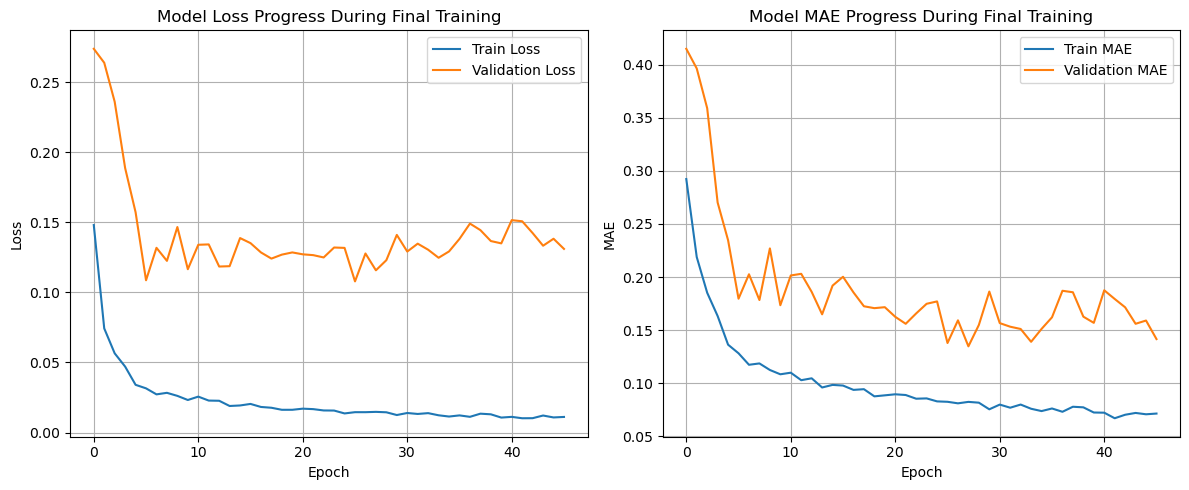

In [58]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress During Final Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_df['mae'], label='Train MAE')
plt.plot(history_df['val_mae'], label='Validation MAE')
plt.title('Model MAE Progress During Final Training')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Membuat Prediksi dan Menghitung MAPE pada Skala Asli ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 628ms/step
Final Test MAPE (Original Scale): 23.09%


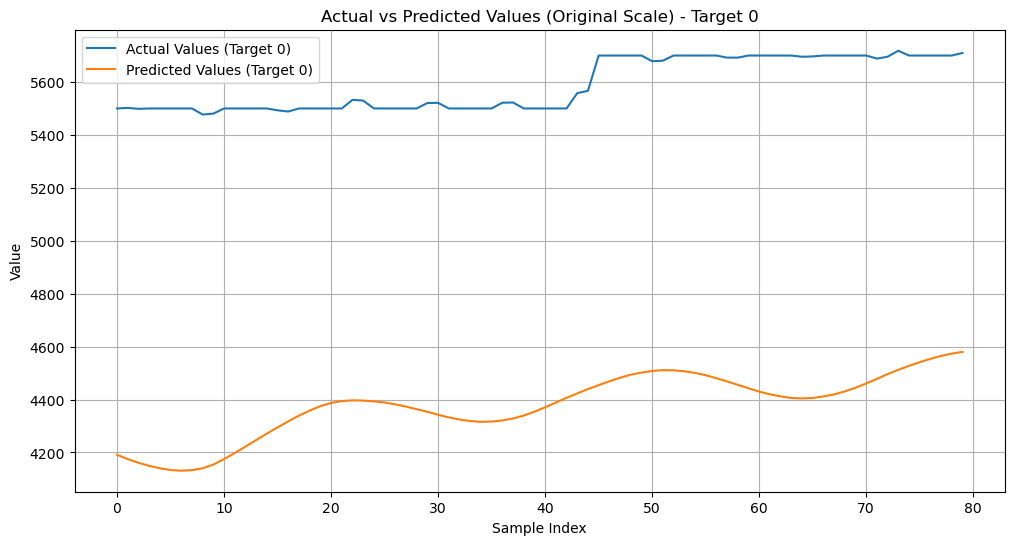

In [59]:
print("\n--- Membuat Prediksi dan Menghitung MAPE pada Skala Asli ---")
y_pred_test_scaled = final_model.predict(X_test_seq)

y_test_original = scaler_target.inverse_transform(y_test_seq)
y_pred_test_original = scaler_target.inverse_transform(y_pred_test_scaled)

def calculate_mape(y_true, y_pred):
    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)
    absolute_percentage_error = np.abs((y_true - y_pred) / y_true_safe)
    mape = np.mean(absolute_percentage_error) * 100
    return mape

test_mape_original = calculate_mape(y_test_original, y_pred_test_original)
print(f"Final Test MAPE (Original Scale): {test_mape_original:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(y_test_original[:, 0], label='Actual Values (Target 0)')
plt.plot(y_pred_test_original[:, 0], label='Predicted Values (Target 0)')
plt.title('Actual vs Predicted Values (Original Scale) - Target 0')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# ''' 
# print("\n--- Membuat Prediksi dan Menghitung MAPE pada Skala Asli ---")
"""
y_pred_test_scaled = final_model.predict(x_all_seq)

y_test_original = scaler_target.inverse_transform(y_all_seq)
y_pred_test_original = scaler_target.inverse_transform(y_pred_test_scaled)

def calculate_mape(y_true, y_pred):
    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)
    absolute_percentage_error = np.abs((y_true - y_pred) / y_true_safe)
    mape = np.mean(absolute_percentage_error) * 100
    return mape

test_mape_original = calculate_mape(y_test_original, y_pred_test_original)
print(f"Final Test MAPE (Original Scale): {test_mape_original:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(y_test_original[:, 0], label='Actual Values (Target 0)')
plt.plot(y_pred_test_original[:, 0], label='Predicted Values (Target 0)')
plt.title('Actual vs Predicted Values (Original Scale) - Target 0')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()
"""

'\ny_pred_test_scaled = final_model.predict(x_all_seq)\n\ny_test_original = scaler_target.inverse_transform(y_all_seq)\ny_pred_test_original = scaler_target.inverse_transform(y_pred_test_scaled)\n\ndef calculate_mape(y_true, y_pred):\n    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)\n    absolute_percentage_error = np.abs((y_true - y_pred) / y_true_safe)\n    mape = np.mean(absolute_percentage_error) * 100\n    return mape\n\ntest_mape_original = calculate_mape(y_test_original, y_pred_test_original)\nprint(f"Final Test MAPE (Original Scale): {test_mape_original:.2f}%")\n\nplt.figure(figsize=(12, 6))\nplt.plot(y_test_original[:, 0], label=\'Actual Values (Target 0)\')\nplt.plot(y_pred_test_original[:, 0], label=\'Predicted Values (Target 0)\')\nplt.title(\'Actual vs Predicted Values (Original Scale) - Target 0\')\nplt.xlabel(\'Sample Index\')\nplt.ylabel(\'Value\')\nplt.legend()\nplt.grid(True)\nplt.show()\n'

In [61]:
def recursive_multi_step_predict(model, initial_sequence, num_prediction_steps, scaler_input, scaler_target, input_feature_cols, target_cols):
    """
    Melakukan prediksi multi-step secara rekursif dengan model LSTM.

    Args:
        model (keras.Model): Model LSTM yang sudah terlatih.
        initial_sequence (np.array): Sekuens awal (terakhir dari data uji) dengan shape (1, n_timesteps, n_features).
                                    HARUS dalam skala NORMALISASI.
        num_prediction_steps (int): Jumlah langkah ke depan yang ingin diprediksi.
        scaler_input (MinMaxScaler): Scaler yang digunakan untuk fitur input.
        scaler_target (MinMaxScaler): Scaler yang digunakan untuk fitur target.
        input_feature_cols (list): Daftar nama kolom fitur input.
        target_cols (list): Daftar nama kolom target.

    Returns:
        pd.DataFrame: DataFrame yang berisi hasil prediksi pada skala asli.
    """
    current_sequence = initial_sequence.copy()
    predictions_scaled = []
    
    # Dapatkan nama-nama fitur siklis jika ada di input_feature_cols
    cyclical_features = [col for col in input_feature_cols if '_sin' in col or '_cos' in col or 'Hari' in col or 'Bulan' in col]
    original_cyclical_names = []
    for cf in cyclical_features:
        if '_sin' in cf:
            original_cyclical_names.append(cf.replace('_sin', ''))
        elif '_cos' in cf:
            original_cyclical_names.append(cf.replace('_cos', ''))
    original_cyclical_names = list(set(original_cyclical_names)) # Ambil nama asli unik

    # Asumsi: kolom 'Tahun' jika ada, juga di antara input_feature_cols
    # Anda perlu cara untuk mengelola bagaimana fitur "masa depan" ini dihasilkan.
    # Untuk fitur siklis, kita bisa memproyeksikan tanggal ke depan.
    # Untuk fitur lain (misal suhu, tekanan), Anda mungkin perlu asumsi (misal, rata-rata, atau 0).
    # Ini adalah bagian paling kompleks dari multi-step forecasting.
    
    # Untuk demo ini, kita akan membuat asumsi sederhana:
    # 1. Fitur siklis dan tahun akan dihitung berdasarkan langkah prediksi.
    # 2. Fitur non-siklis akan dianggap 0 (atau rata-rata) di masa depan (INI HANYA CONTOH, BUKAN PRAKTIK TERBAIK)
    #    Praktik terbaik: gunakan prediksi dari model lain, atau rata-rata historis, atau diasumsikan konstan.

    # Dapatkan tanggal/waktu dari data uji terakhir untuk proyeksi masa depan
    # Asumsi: Anda memiliki kolom tanggal/waktu di df asli dan bisa mengidentifikasi tanggal terakhir.
    # Jika tidak ada tanggal, prediksi ini hanya akan berupa "langkah ke depan" tanpa tanggal spesifik.
    
    # Ini adalah contoh paling sederhana tanpa memperhitungkan tanggal asli.
    # Jika Anda memiliki kolom tanggal, Anda perlu memperpanjang rentang tanggal.
    
    # Dapatkan kolom fitur non-siklis
    non_cyclical_features = [col for col in input_feature_cols if col not in cyclical_features and col != 'year']
    
    for i in range(num_prediction_steps):
        # Prediksi satu langkah ke depan
        next_step_pred_scaled = model.predict(current_sequence, verbose=0)
        predictions_scaled.append(next_step_pred_scaled[0]) # Ambil hasil prediksi

        # --- Perbarui current_sequence untuk prediksi langkah berikutnya ---
        # 1. Geser sekuens ke kiri (buang langkah waktu tertua)
        new_sequence = np.roll(current_sequence, -1, axis=1) # Menggeser baris (timesteps) ke atas
        
        # 2. Buat baris data baru untuk langkah waktu berikutnya (fitur input masa depan)
        #    Ini adalah bagian krusial dan paling sulit.
        #    Anda harus membuat 1 baris baru dengan n_features yang diprediksi/diasumsikan.
        
        #    a. Gunakan prediksi target (y_hat) sebagai bagian dari fitur input jika relevan
        #       (misal, jika fitur input Anda juga mengandung target_lag)
        #       Untuk saat ini, model Anda memprediksi target, bukan fitur input.
        #       Jadi, kita fokus pada bagaimana mendapatkan fitur input untuk langkah berikutnya.
        
        #    b. Untuk fitur non-siklis (e.g., suhu, tekanan):
        #       Ini adalah asumsi paling lemah. Idealnya, fitur ini juga diprediksi/diketahui.
        #       Untuk demo ini, kita akan mengisi dengan 0 atau rata-rata dari data terakhir.
        #       Mari kita isi dengan nilai rata-rata dari fitur non-siklis di current_sequence
        future_input_features_scaled = np.zeros((1, n_features))
        
        # Mengisi fitur non-siklis:
        # Menemukan indeks fitur non-siklis di X_all atau input_feature_cols
        for k, col_name in enumerate(input_feature_cols):
            if col_name in non_cyclical_features:
                col_index = input_feature_cols.index(col_name)
                # Mengisi dengan rata-rata dari kolom tersebut di sekuens terakhir
                # Atau, lebih baik, dengan nilai dari langkah terakhir di sekuens (asumsi konstan)
                future_input_features_scaled[0, col_index] = current_sequence[0, -1, col_index]
            elif col_name == 'year':
                col_index = input_feature_cols.index(col_name)
                # Asumsi tahun konstan atau meningkat (misal 2023 -> 2024 dst)
                # Jika 2022-2023, maka kemungkinan tahun_terakhir + (i / 365) untuk interpolasi
                # Untuk sederhana, asumsikan tahun terakhir di current_sequence
                future_input_features_scaled[0, col_index] = current_sequence[0, -1, col_index]
                # Jika ingin memajukan tahun, Anda perlu logika lebih kompleks berdasarkan i
                # Misalnya, jika i melewati 365 hari, tahun maju 1.
            else: # Ini adalah fitur siklis (_sin/_cos)
                pass # Akan dihitung di bawah
        
        #    c. Untuk fitur siklis (sin/cos): Hitung berdasarkan proyeksi tanggal
        #       Anda perlu melacak "tanggal" internal untuk memproyeksikan hari/bulan/tahun.
        #       Ini tidak ada di dalam `X_test_seq` secara langsung, jadi harus di-manage secara terpisah.
        #       Ini adalah penyederhanaan. Dalam aplikasi nyata, Anda akan memiliki tanggal aktual.
        
        # Asumsi untuk demo: kita proyeksikan bulan dan hari dari nilai terakhir di sekuens
        # Ini memerlukan inverse_transform dan kemudian re-transform
        # Contoh: mendapatkan bulan/hari dari nilai terakhir di current_sequence
        # Ini bagian yang tricky karena sin/cos tidak langsung inverse_transform ke angka bulat.
        
        # CARA LEBIH SIMPEL DAN UMUM:
        # Jika Anda ingin memproyeksikan fitur siklis, Anda perlu mengetahui tanggal/waktu yang sesuai
        # dengan langkah `i` ke depan.
        # Misalnya, jika langkah terakhir di X_test_seq adalah 2023-12-31,
        # maka langkah i=0 adalah 2024-01-01, i=1 adalah 2024-01-02, dst.
        # Dari tanggal tersebut, Anda ekstrak hari/bulan dan hitung sin/cos.
        
        # Karena kita tidak memiliki informasi tanggal di sini, kita akan mengasumsikan
        # nilai sin/cos dari elemen terakhir di current_sequence akan dipakai,
        # tapi ini BUKAN proyeksi yang akurat untuk fitur siklis.
        # Jika ada fitur siklis, Anda perlu melacak tanggal aktual dari X_raw atau df.
        
        # Untuk tujuan demo: kita akan mencari indeks kolom _sin dan _cos
        # dan mempertahankan nilainya dari langkah terakhir di sekuens,
        # ini adalah simplifikasi yang tidak akan memproyeksikan siklus dengan benar
        # jika periode prediksi panjang.
        for k, col_name in enumerate(input_feature_cols):
            if '_sin' in col_name or '_cos' in col_name:
                col_index = input_feature_cols.index(col_name)
                future_input_features_scaled[0, col_index] = current_sequence[0, -1, col_index]

        # 3. Gabungkan prediksi target (jika relevan sebagai input) dan fitur input lainnya
        #    Jika model Anda juga membutuhkan prediksi target sebelumnya sebagai input fitur,
        #    Anda akan menambahkannya di sini. Untuk model ini, tidak ada.
        
        # 4. Tempatkan baris data baru ke posisi terakhir (langkah waktu terbaru)
        new_sequence[0, -1, :] = future_input_features_scaled # Memasukkan baris fitur baru

        current_sequence = new_sequence # Perbarui sekuens untuk iterasi berikutnya

    # Ubah hasil prediksi dari skala normalisasi ke skala asli
    predictions_original = scaler_target.inverse_transform(np.array(predictions_scaled))

    # Buat DataFrame dari hasil prediksi
    df_predictions = pd.DataFrame(predictions_original, columns=target_cols)
    return df_predictions

In [62]:
# 1. Ambil sekuens terakhir dari X_test_seq untuk inisialisasi
# Ini akan menjadi sekuens yang digunakan model untuk prediksi pertama.
# Pastikan X_test_seq memiliki setidaknya n_timesteps sampel.
if X_test_seq.shape[0] < n_timesteps:
    raise ValueError("X_test_seq tidak cukup panjang untuk membuat sekuens awal.")

initial_input_sequence = X_test_seq[-1:].copy() # Ambil sekuens terakhir, pastikan shape (1, n_timesteps, n_features)

num_future_steps = 10 # Misalnya, ingin memprediksi 10 langkah ke depan

print(f"\nMemulai prediksi rekursif untuk {num_future_steps} langkah...")
forecast_df = recursive_multi_step_predict(
    final_model,
    initial_input_sequence,
    num_future_steps,
    scaler_input,
    scaler_target,
    input_kolom,
    target_kolom
)

print("\nHasil Prediksi Recursive Multi-Step (Skala Asli):")
print(forecast_df)


Memulai prediksi rekursif untuk 10 langkah...

Hasil Prediksi Recursive Multi-Step (Skala Asli):
   Harga Petani  Harga Pengecer    Luas Panen  Produktivitas      Produksi
0   4580.080078     4932.260742  13075.854492      73.092163  80709.156250
1   4584.266602     4943.698730  12509.096680      73.059280  77124.000000
2   4586.622559     4951.602051  12064.947266      73.035339  74394.476562
3   4587.403320     4956.659668  11734.060547      73.018372  72429.546875
4   4586.819824     4960.030762  11504.891602      73.005669  71162.460938
5   4585.655273     4961.002930  11347.847656      72.997322  70327.312500
6   4584.247559     4960.219238  11248.114258      72.992546  69866.125000
7   4582.513672     4958.365723  11187.625977      72.989265  69589.796875
8   4580.715820     4955.948730  11156.087891      72.986549  69444.226562
9   4578.933594     4953.255859  11144.678711      72.983940  69388.757812


In [64]:
df_x=df_merged[(df_merged['Tanggal'] >= '2024-01-01') & (df_merged['Tanggal'] <= '2024-12-31')].copy()

In [66]:
df_x.reset_index(drop=True, inplace=True)

In [70]:
df_x

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi
0,Jagung Pipil Kering,2024-01-01,NaN,NaN,Jagung,Q1-2024,NaN,NaN,NaN,NaN
1,Jagung Pipil Kering,2024-01-02,5700.0,6000.0,Jagung,Q1-2024,NaN,NaN,NaN,NaN
2,Jagung Pipil Kering,2024-01-03,5700.0,6000.0,Jagung,Q1-2024,NaN,NaN,NaN,NaN
3,Jagung Pipil Kering,2024-01-04,5700.0,6000.0,Jagung,Q1-2024,NaN,NaN,NaN,NaN
4,Jagung Pipil Kering,2024-01-05,5700.0,6000.0,Jagung,Q1-2024,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
361,Jagung Pipil Kering,2024-12-27,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
362,Jagung Pipil Kering,2024-12-28,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
363,Jagung Pipil Kering,2024-12-29,3900.0,4000.0,Jagung,Q3-2024,NaN,NaN,NaN,NaN
364,Jagung Pipil Kering,2024-12-30,NaN,NaN,Jagung,Q3-2024,NaN,NaN,NaN,NaN


In [71]:
df_x_harga=df_x['Harga Petani']

In [72]:
df_x_harga

0         NaN
1      5700.0
2      5700.0
3      5700.0
4      5700.0
        ...  
361    3900.0
362    3900.0
363    3900.0
364       NaN
365       NaN
Name: Harga Petani, Length: 366, dtype: float64

In [74]:
test_mape_original = calculate_mape(df_x_harga, forecast_df['Harga Petani'])
print(f"Final Test MAPE (Original Scale): {test_mape_original:.2f}%")

Final Test MAPE (Original Scale): 19.58%
